In [1]:
import os
import pandas as pd
import numpy as np
from IPython.display import Image, display

# Optimize pandas display options
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

def optimize_memory(df):
    for col in df.columns:
        if df[col].dtype == 'float64':
            df[col] = df[col].astype('float32')
        elif df[col].dtype == 'int64':
            df[col] = df[col].astype('int32')
    return df

print("Loading preprocessed dataset (1.8M rows) from data folder...")
df = pd.read_csv('data/Cleaned_Accident_data_2008_2020.csv')
df = optimize_memory(df)
print(f"Dataset loaded successfully! Shape: {df.shape}")


Loading preprocessed dataset (1.8M rows) from data folder...


Dataset loaded successfully! Shape: (1804624, 34)


In [2]:
from src.statistical_tests import generate_descriptive_summary

summary_df = generate_descriptive_summary(df)
display(summary_df)


,Column Name,Data Type,Non-Null Count,Null Percentage (%),Unique Values,Mean,Median,Std Dev,Min,Max,Skewness
0,accident_year,int32,1804624,0.00%,13,2013.492,2013.000,3.670,2008.000,2020.000,0.131
1,longitude,float32,1804624,0.00%,1345645,-1.353,-1.279,1.399,-7.525,1.762,-0.451
2,latitude,float32,1804624,0.00%,780877,52.516,52.095,1.442,49.912,60.764,1.073
3,police_force,int32,1804624,0.00%,52,29.895,30.000,25.351,1.000,99.000,0.844
4,accident_severity,int32,1804624,0.00%,3,2.822,3.000,0.413,1.000,3.000,-2.203
5,number_of_vehicles,object,1804624,0.00%,4,N/A,N/A,N/A,N/A,N/A,N/A
6,number_of_casualties,object,1804624,0.00%,5,N/A,N/A,N/A,N/A,N/A,N/A
7,day_of_week,int32,1804624,0.00%,7,4.111,4.000,1.921,1.000,7.000,-0.063
8,local_authority_district,int32,1804624,0.00%,417,343.409,322.000,259.311,-1.000,941.000,0.499
9,first_road_class,int32,1804624,0.00%,6,4.121,4.000,1.438,1.000,6.000,0.106


D:\CHROME DOWNLOADS\Road_Accident_PRedictio_Datasets\Road_Accident_Severity_Project\src\statistical_tests.py:109: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


D:\CHROME DOWNLOADS\Road_Accident_PRedictio_Datasets\Road_Accident_Severity_Project\src\statistical_tests.py:139: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


D:\CHROME DOWNLOADS\Road_Accident_PRedictio_Datasets\Road_Accident_Severity_Project\src\statistical_tests.py:167: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


Univariate plots successfully generated!

=== Target Variable Distribution ===


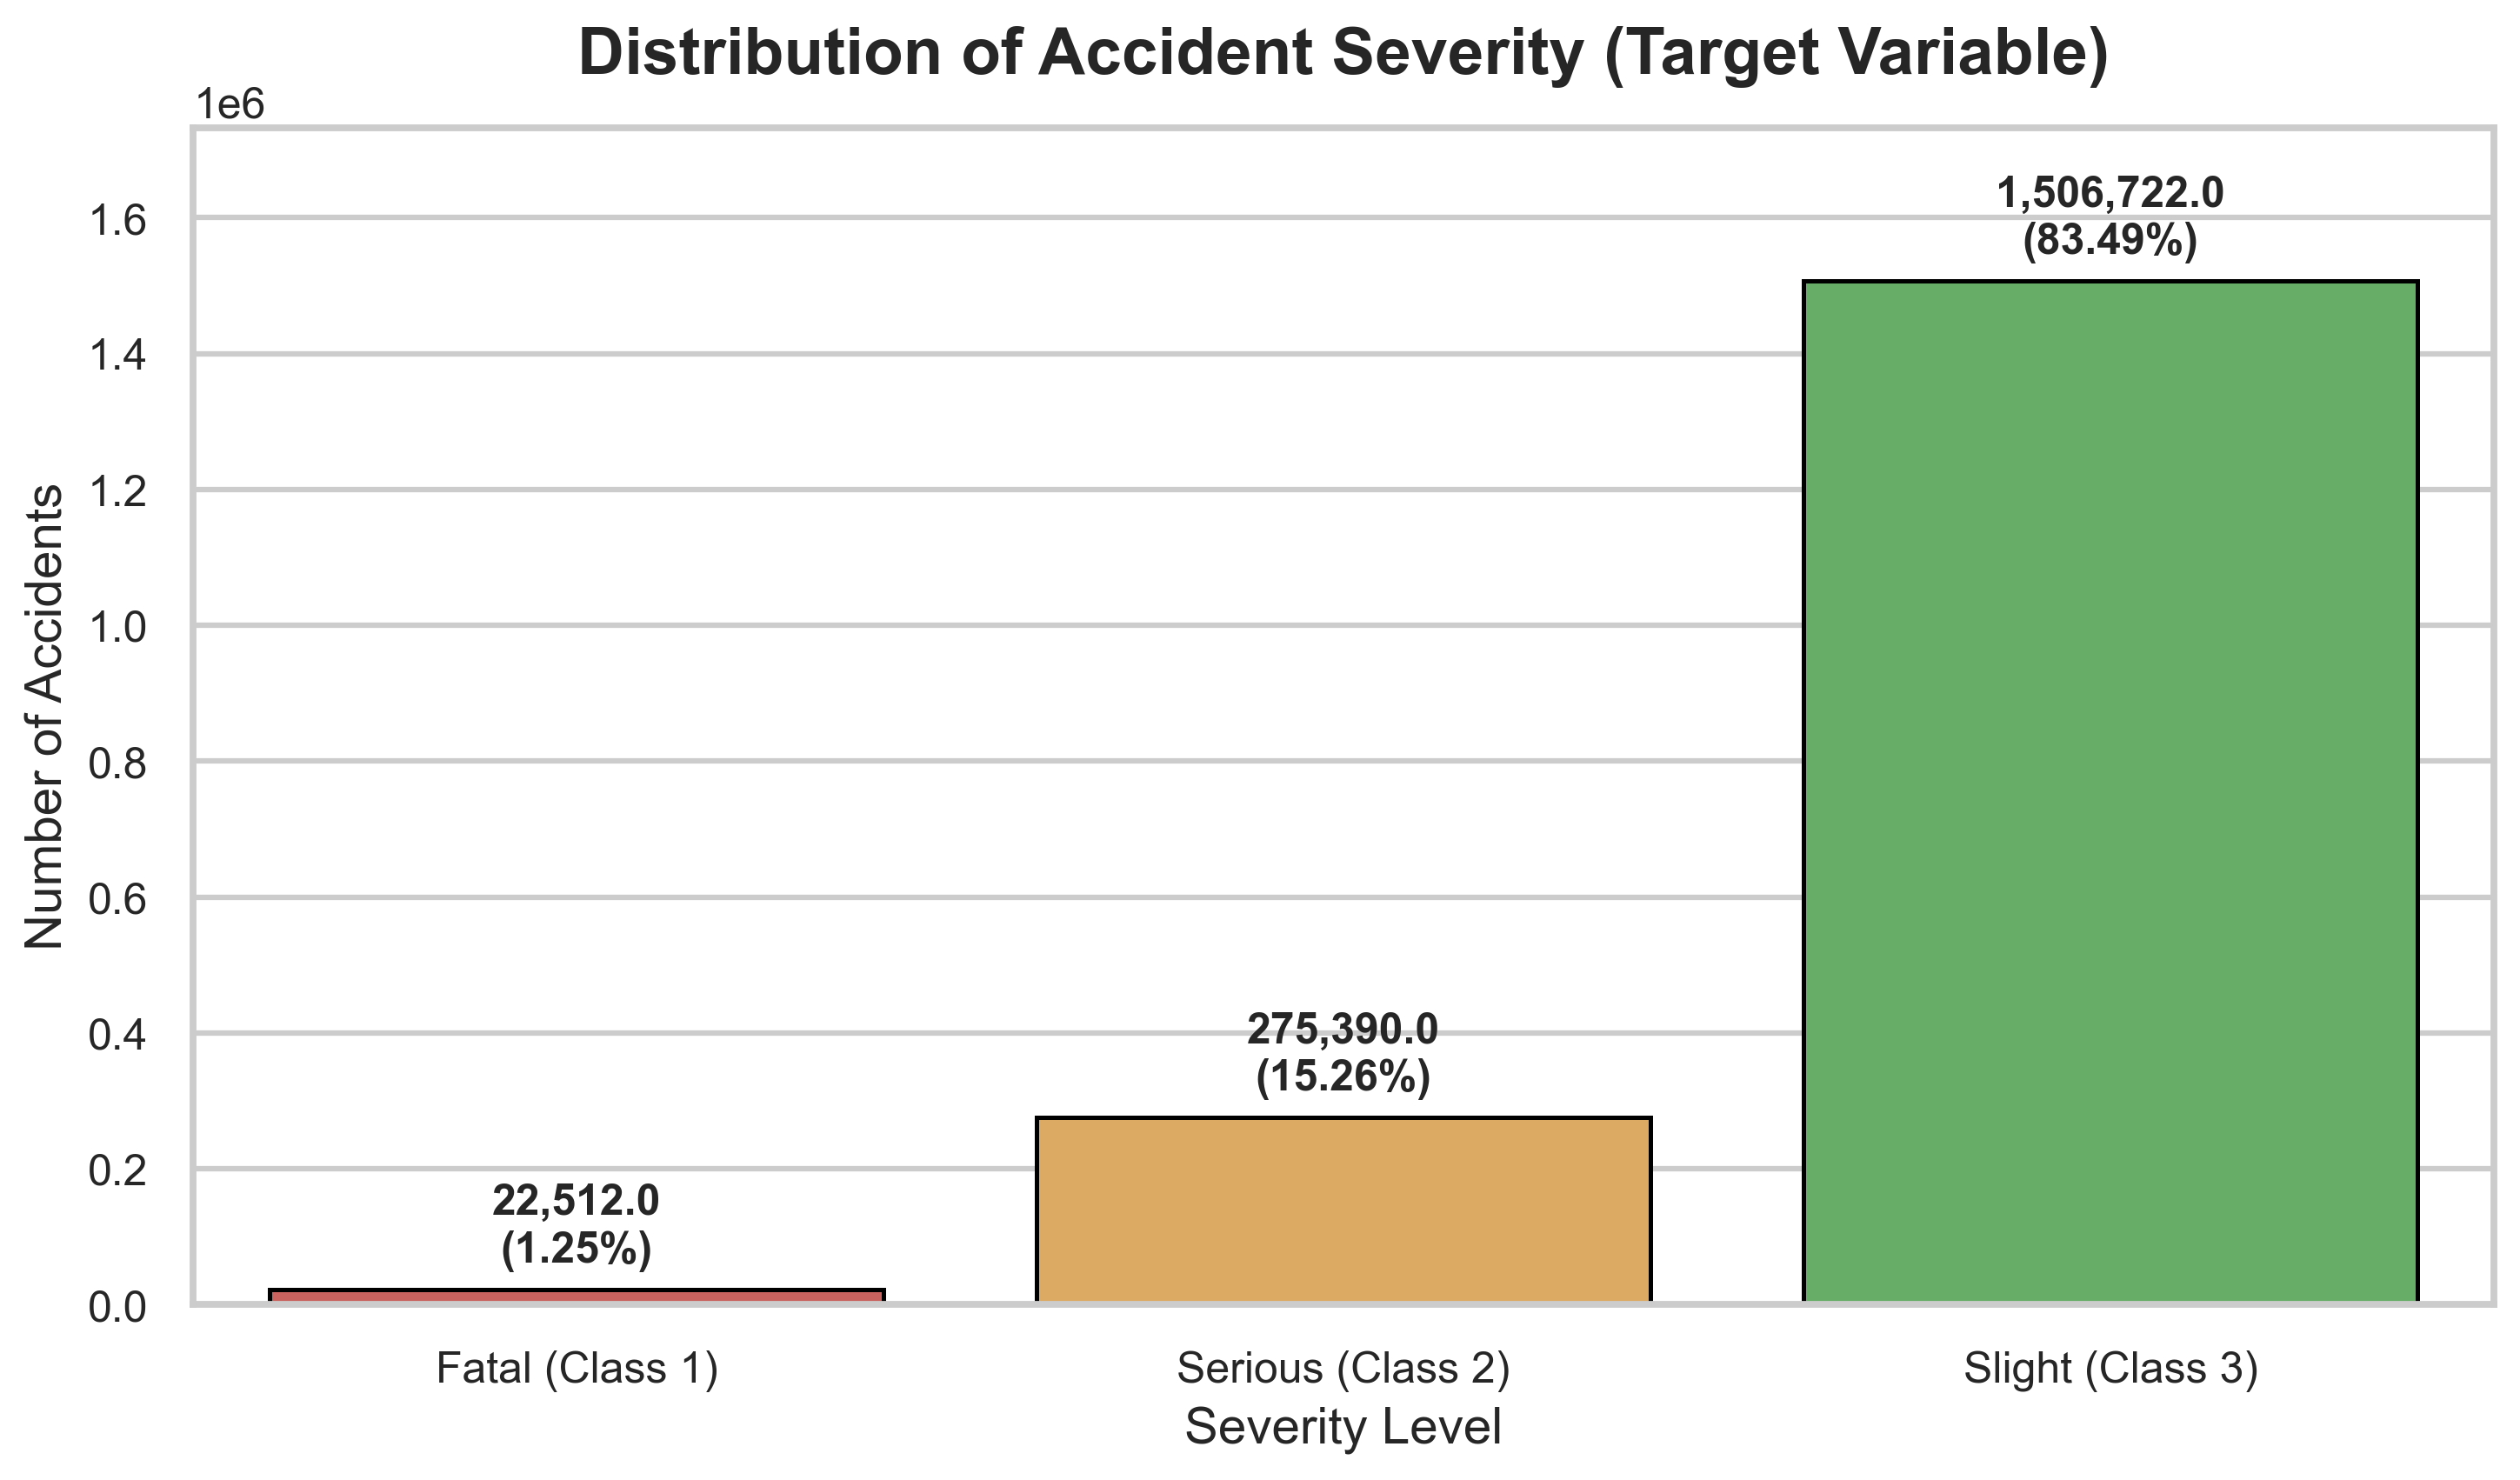

In [3]:
from src.statistical_tests import plot_univariate_distributions

plots = plot_univariate_distributions(df)
print("Univariate plots successfully generated!")

# Display target variable distribution
print("\n=== Target Variable Distribution ===")
display(Image(filename=plots['target']))


=== Speed Limit Distribution ===


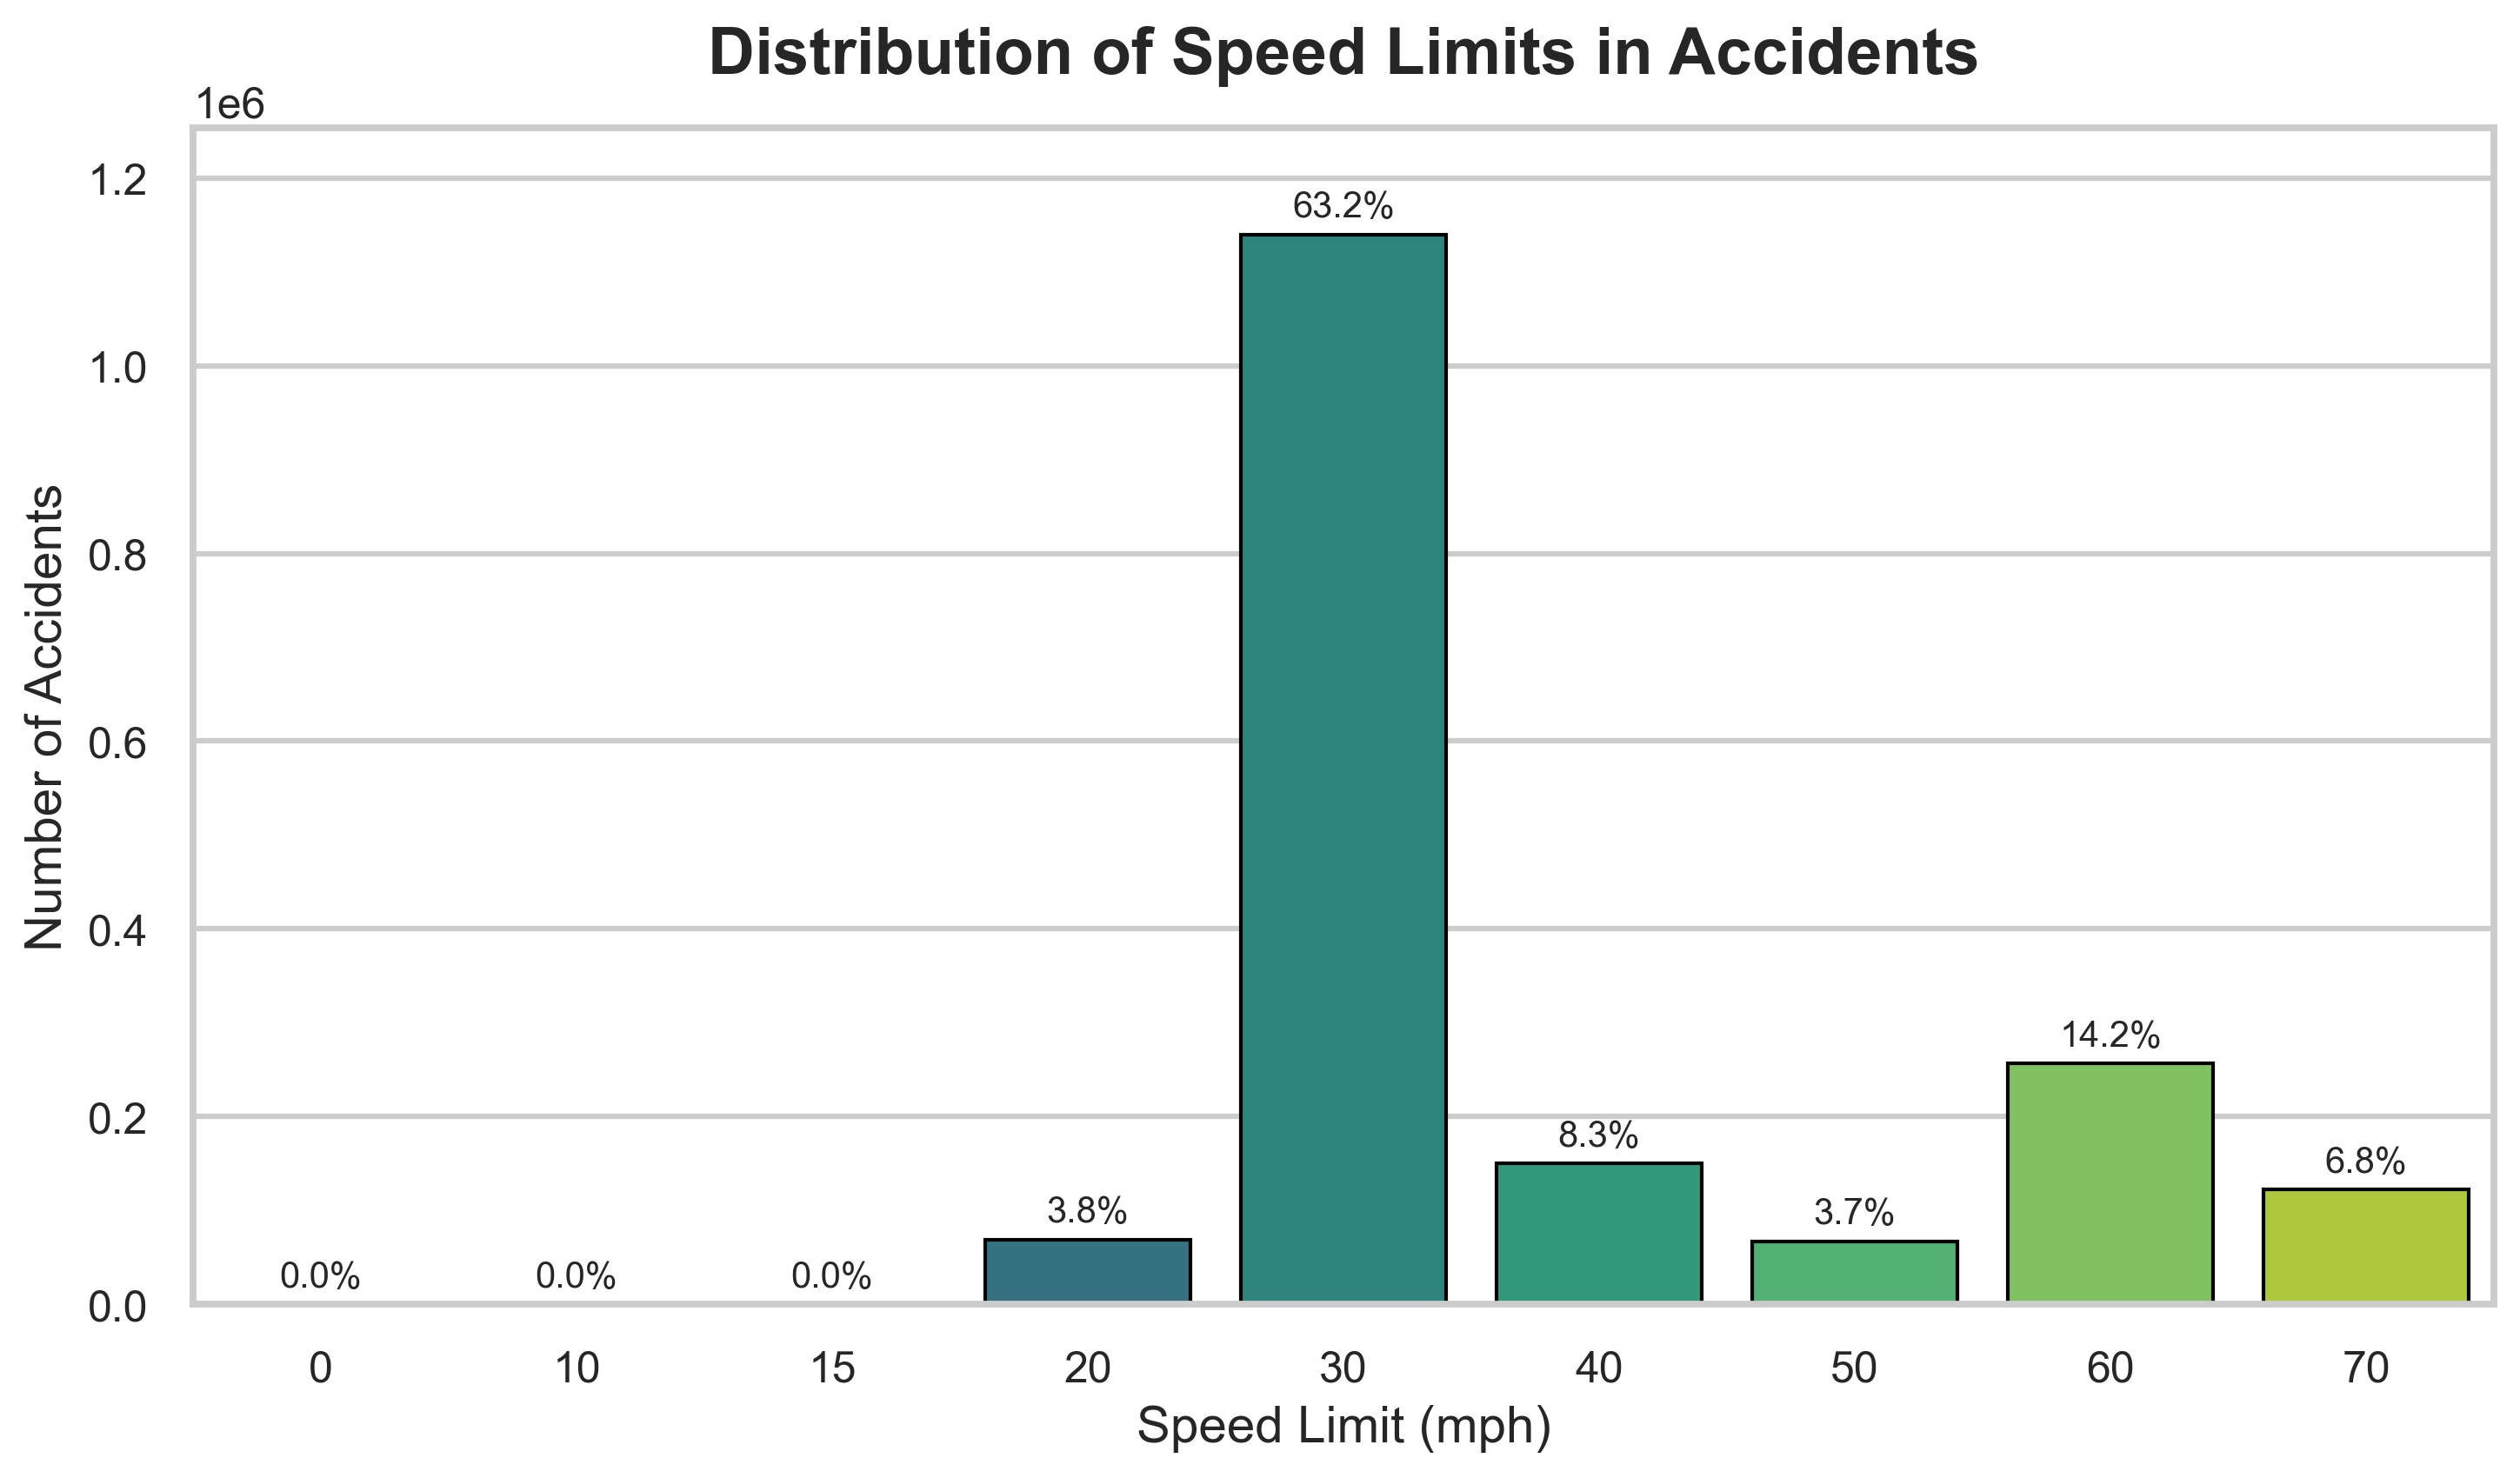


=== Hourly Distribution of Accidents ===


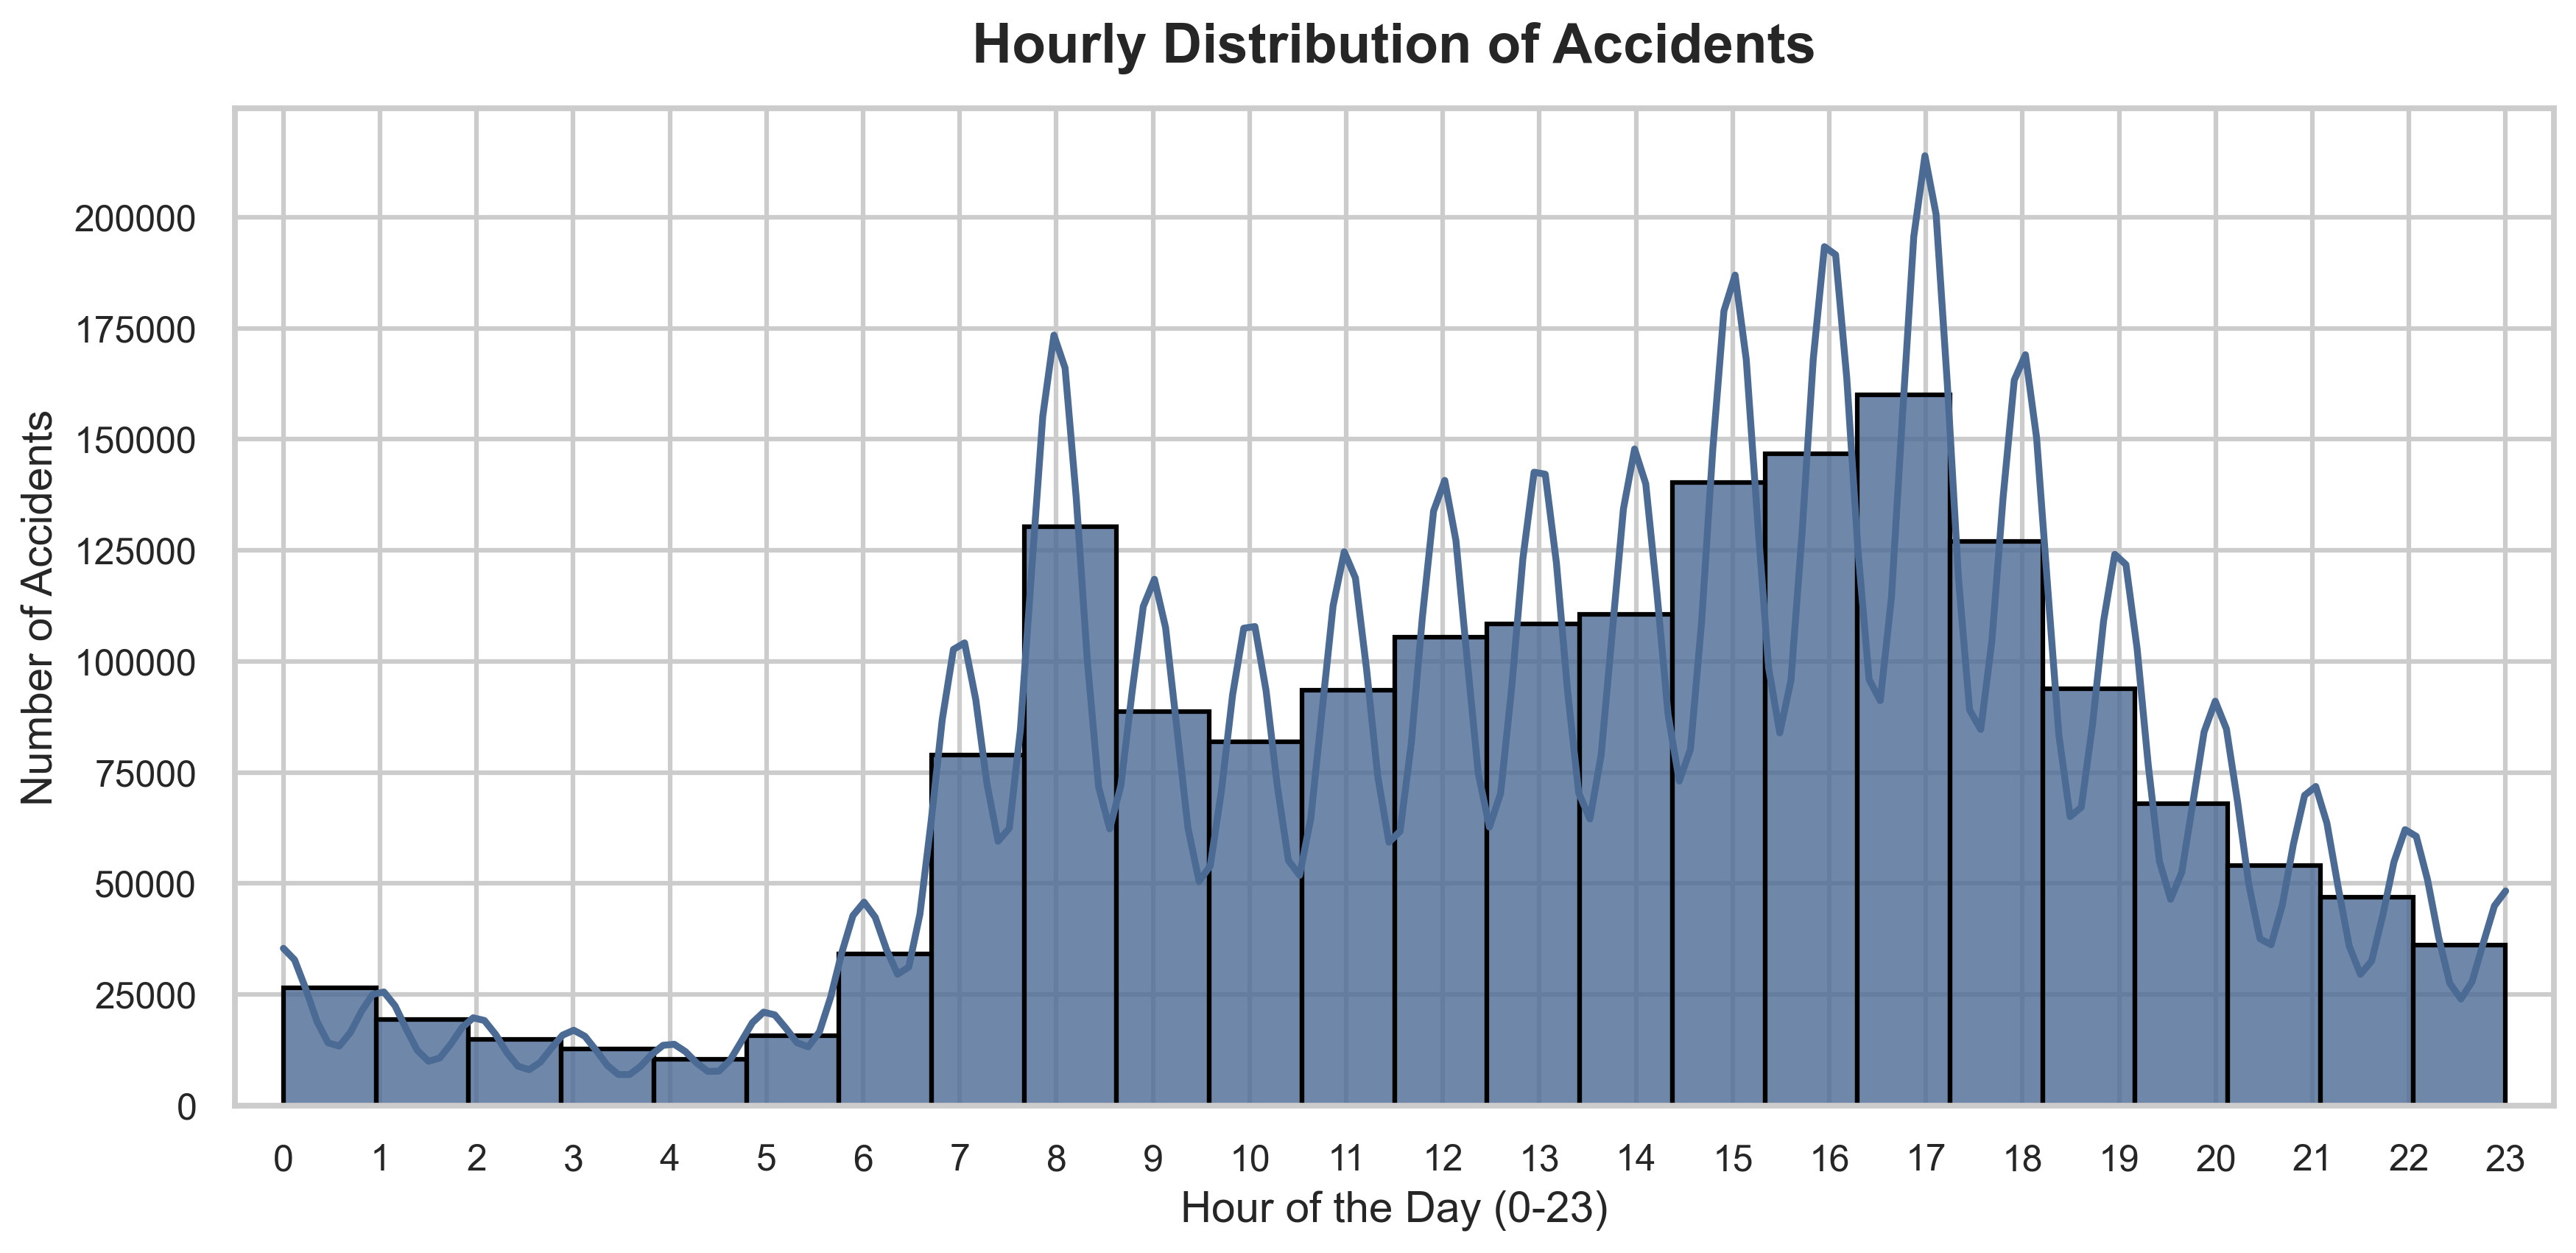

In [4]:
print("=== Speed Limit Distribution ===")
display(Image(filename=plots['speed_limit']))

print("\n=== Hourly Distribution of Accidents ===")
display(Image(filename=plots['accident_hour']))


Bivariate plots successfully generated!

=== Urban vs. Rural Severity Proportions ===


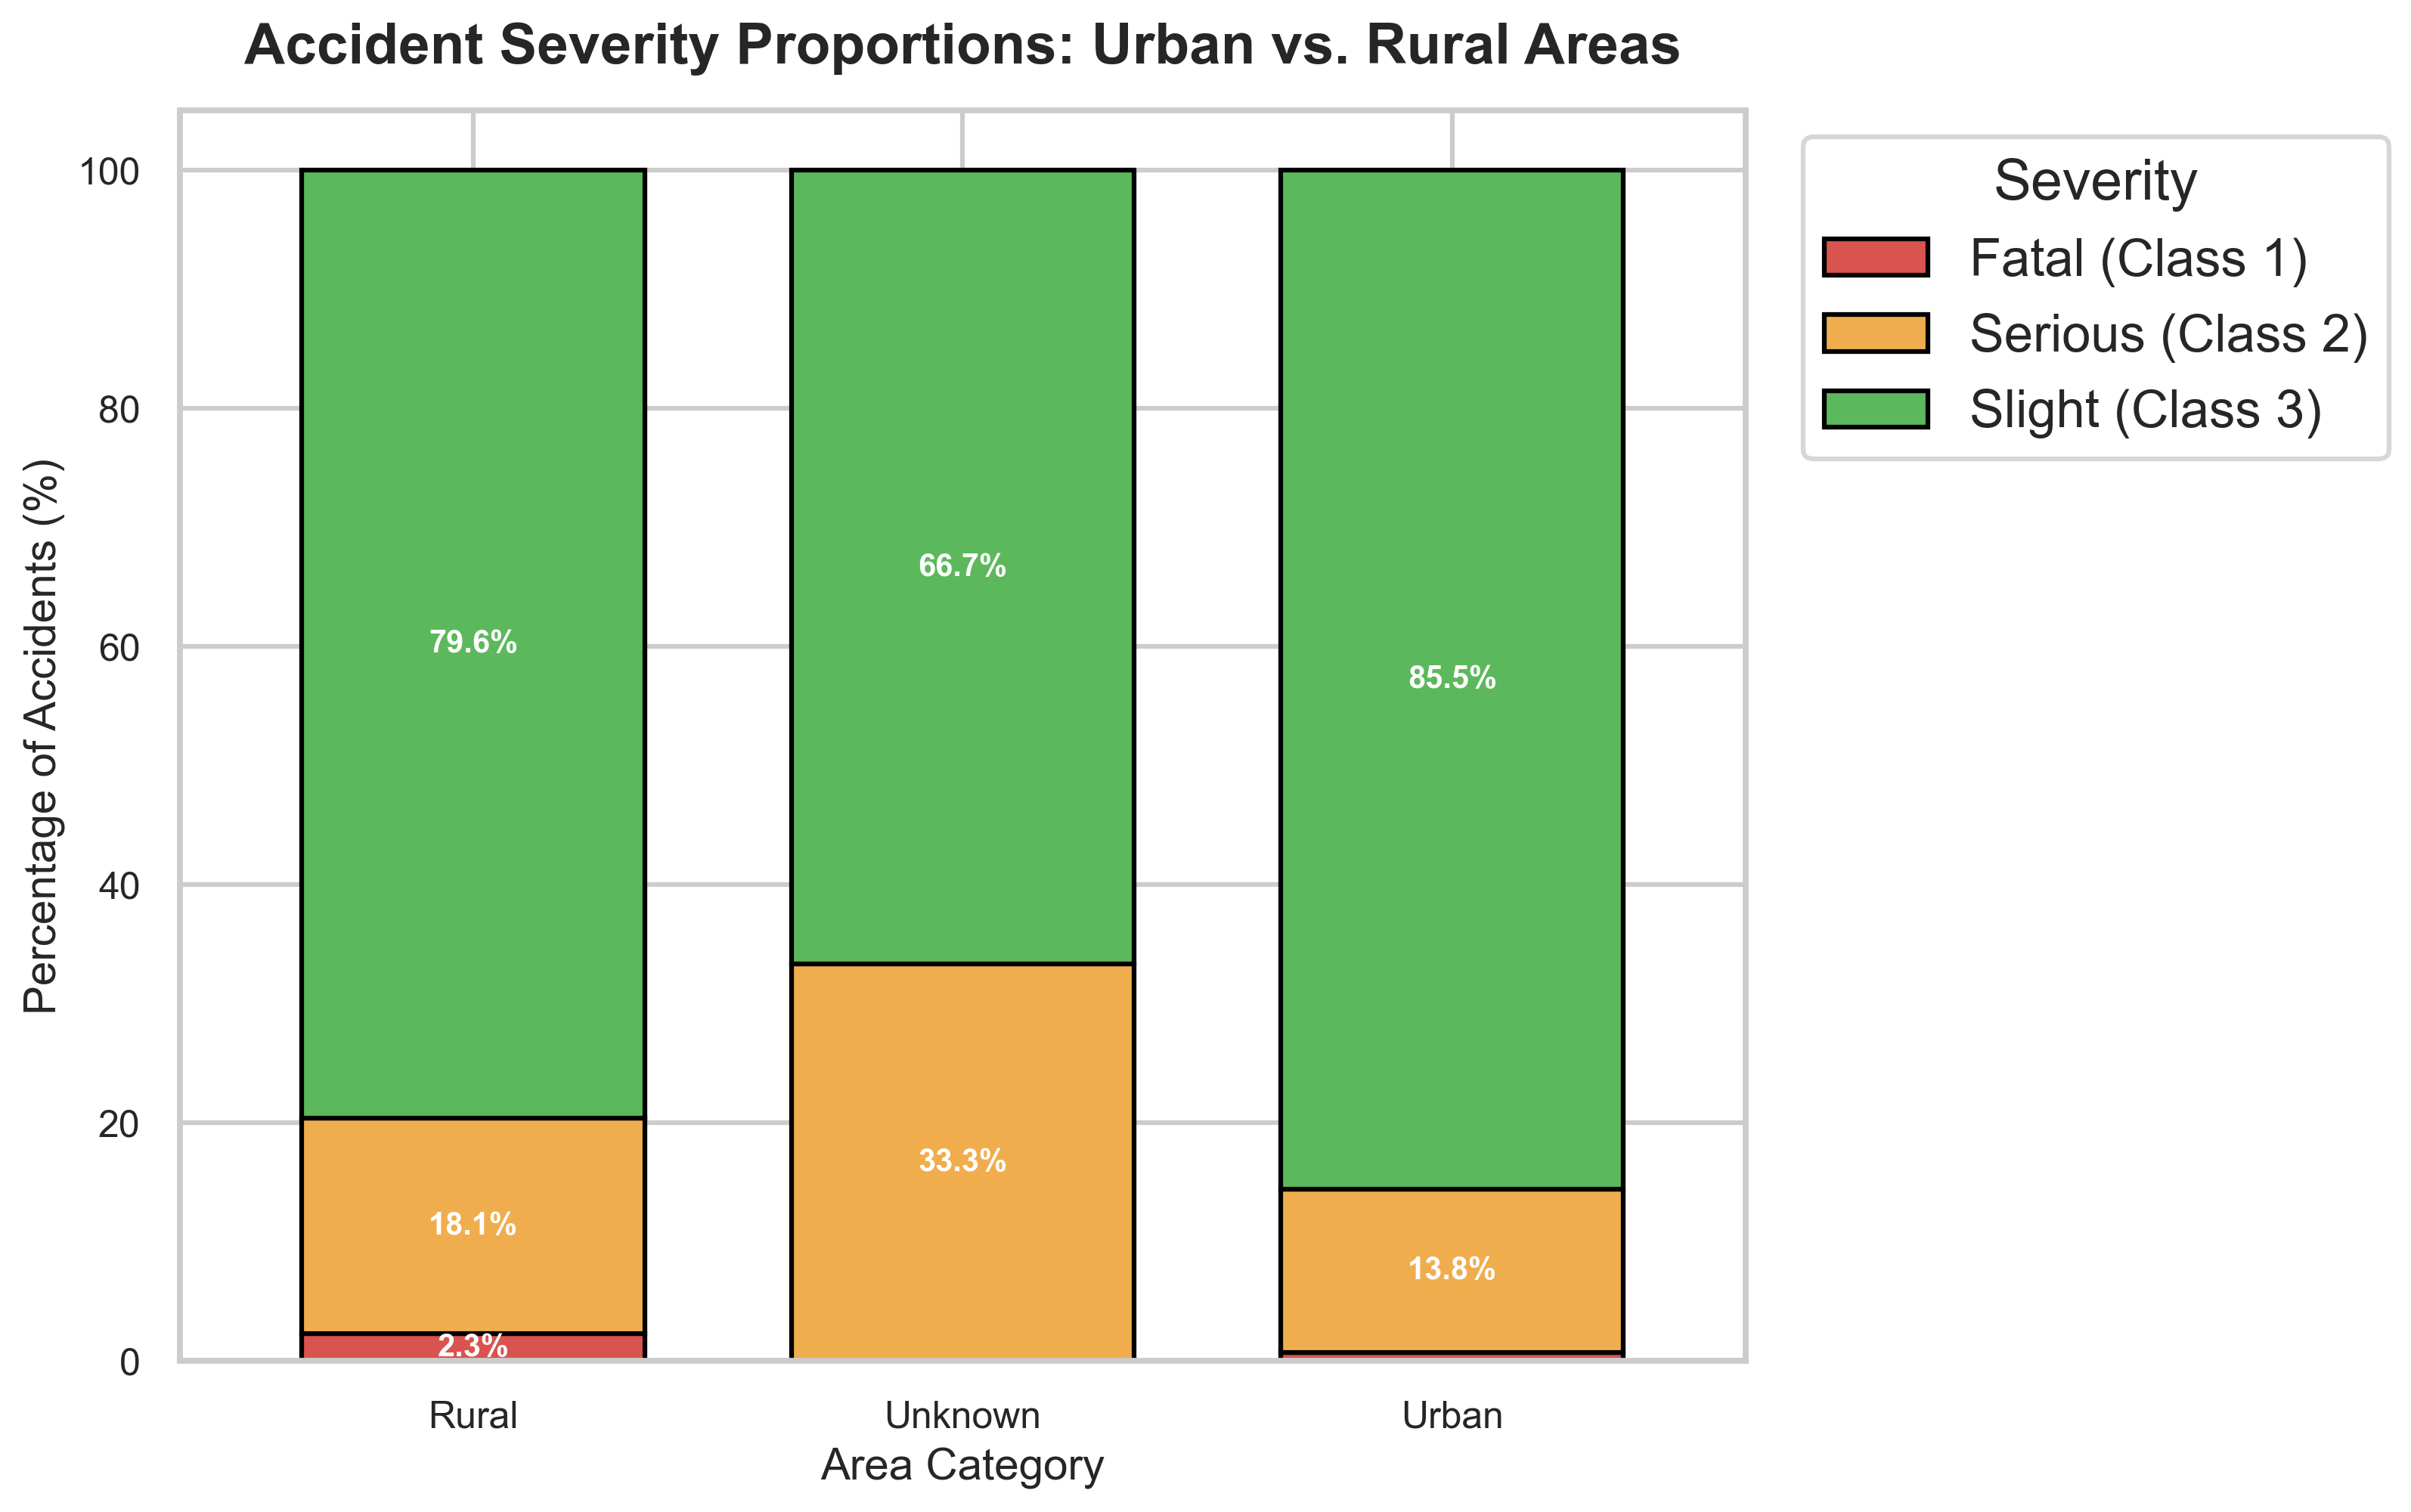


=== Speed Limit Severity Proportions ===


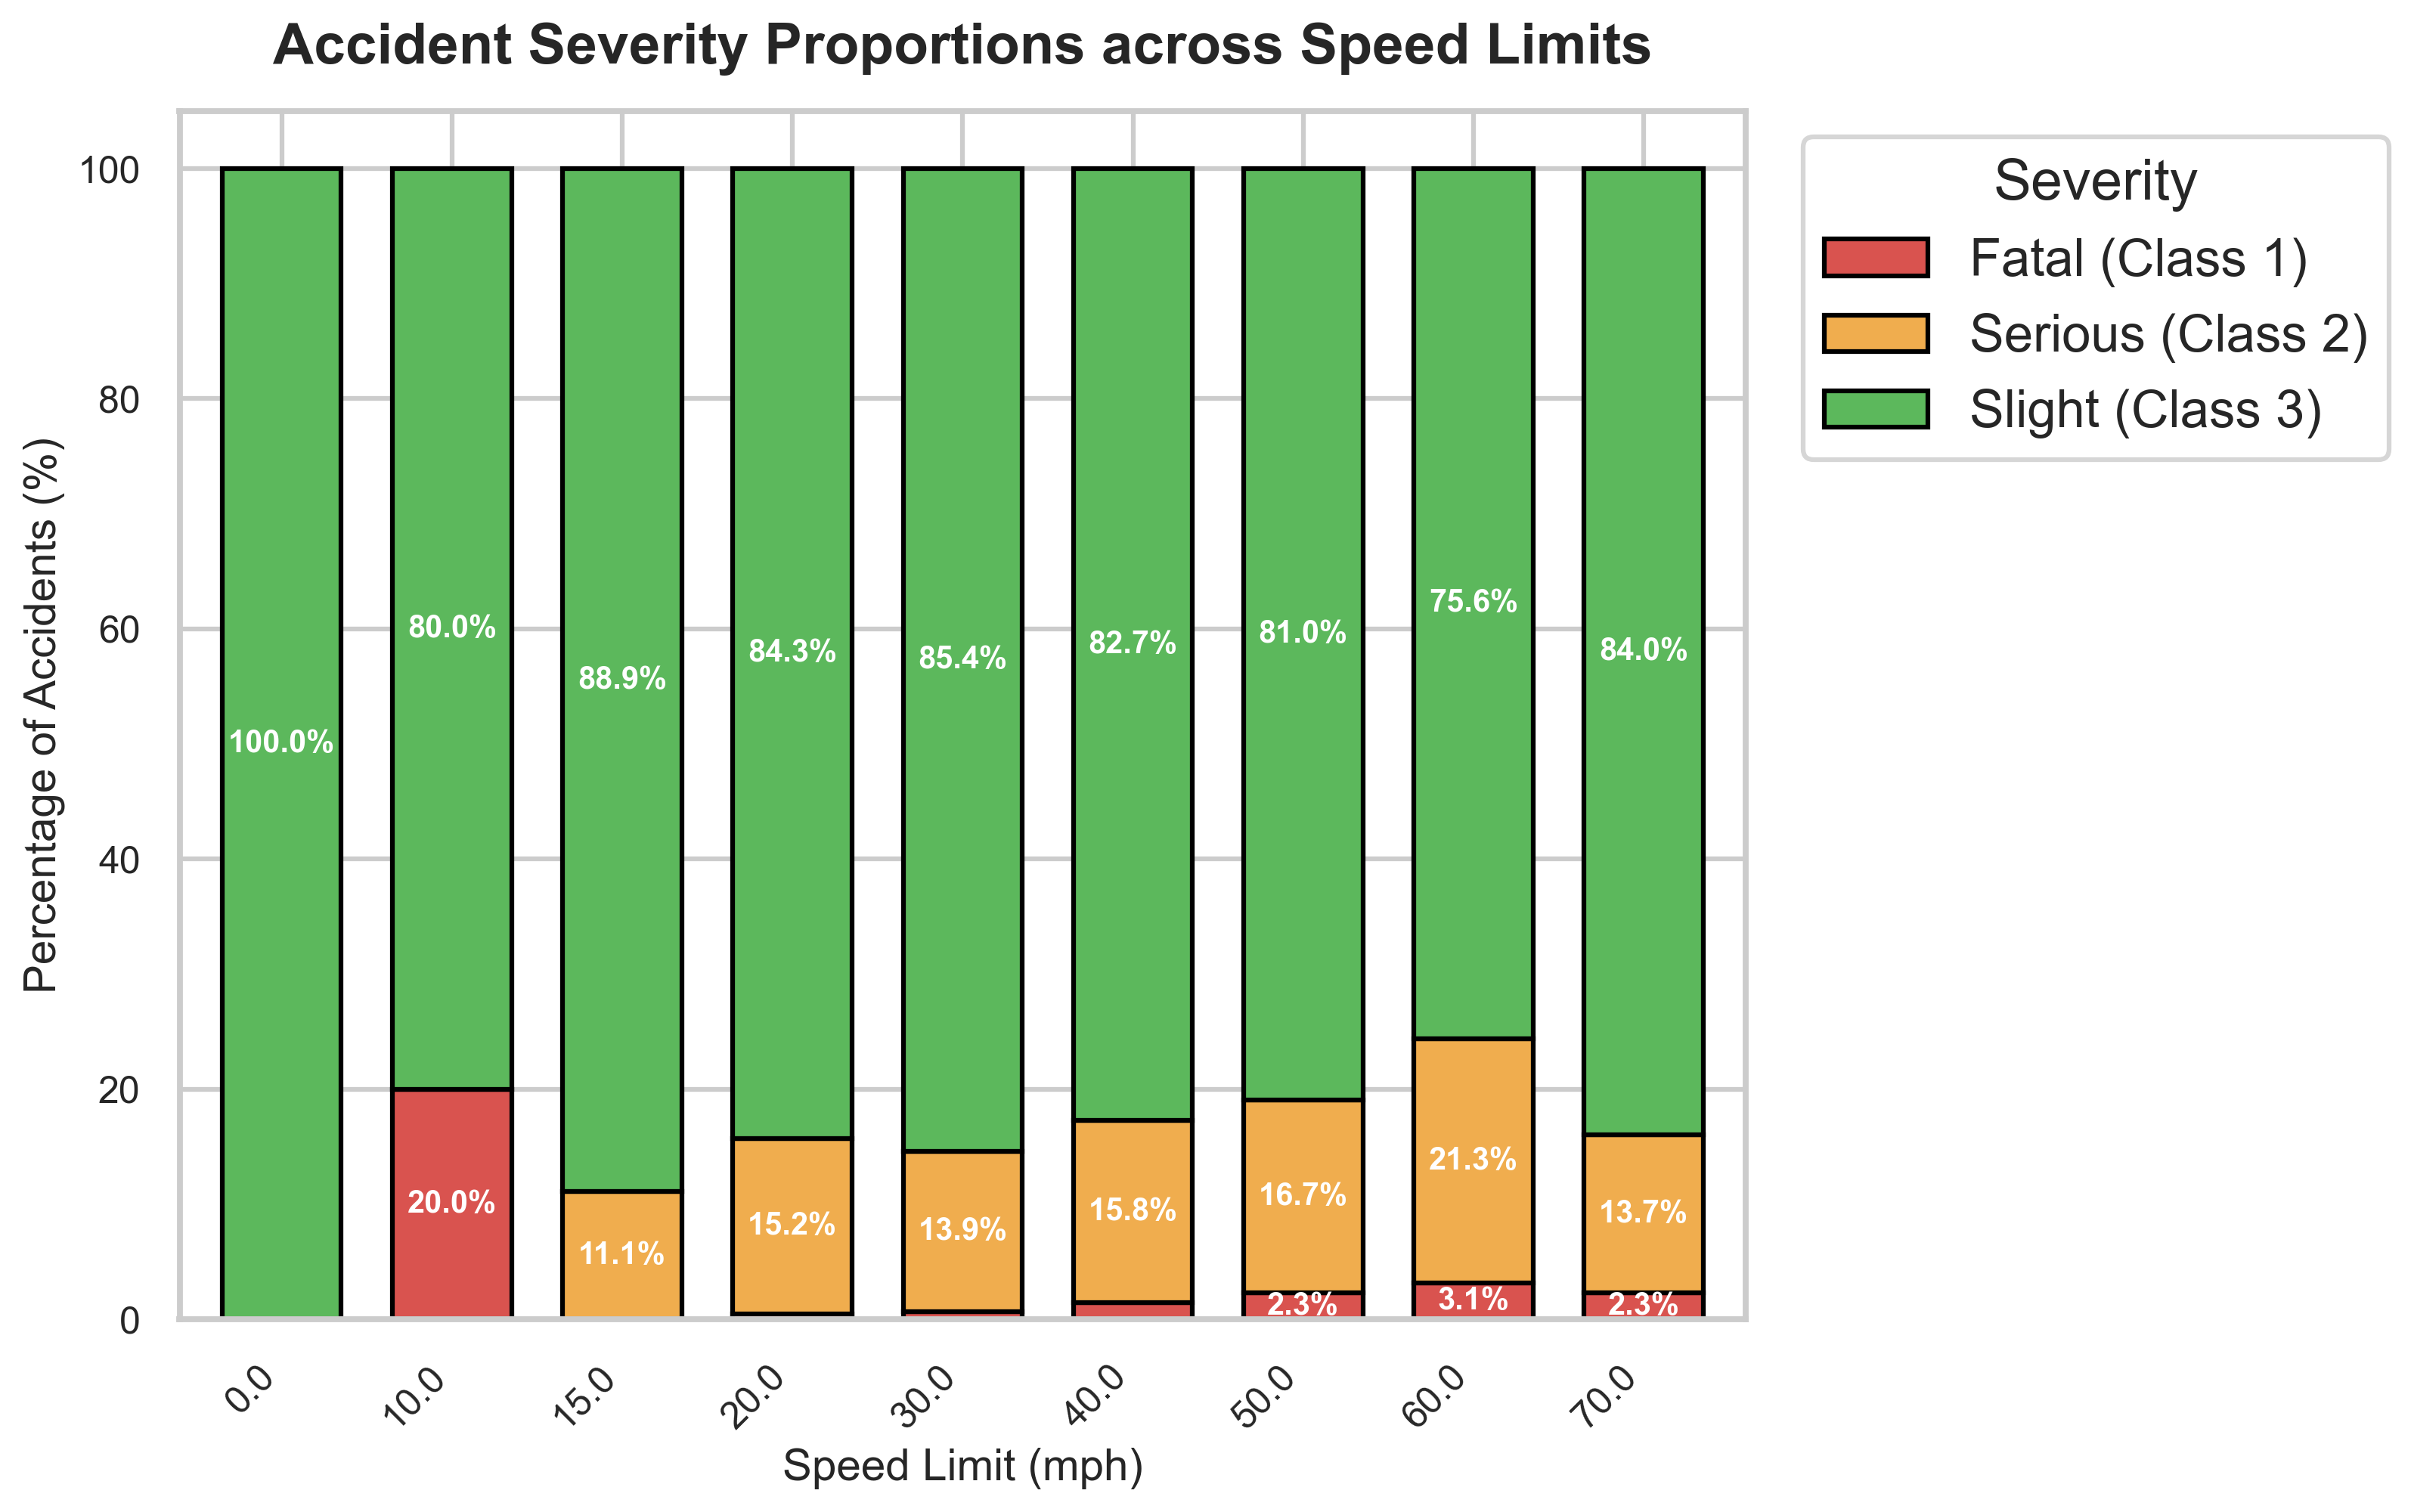

In [5]:
from src.statistical_tests import plot_bivariate_analysis

bivariate_plots = plot_bivariate_analysis(df)
print("Bivariate plots successfully generated!")

print("\n=== Urban vs. Rural Severity Proportions ===")
display(Image(filename=bivariate_plots['urban_rural']))

print("\n=== Speed Limit Severity Proportions ===")
display(Image(filename=bivariate_plots['speed_limit']))


=== Weather Severity Proportions ===


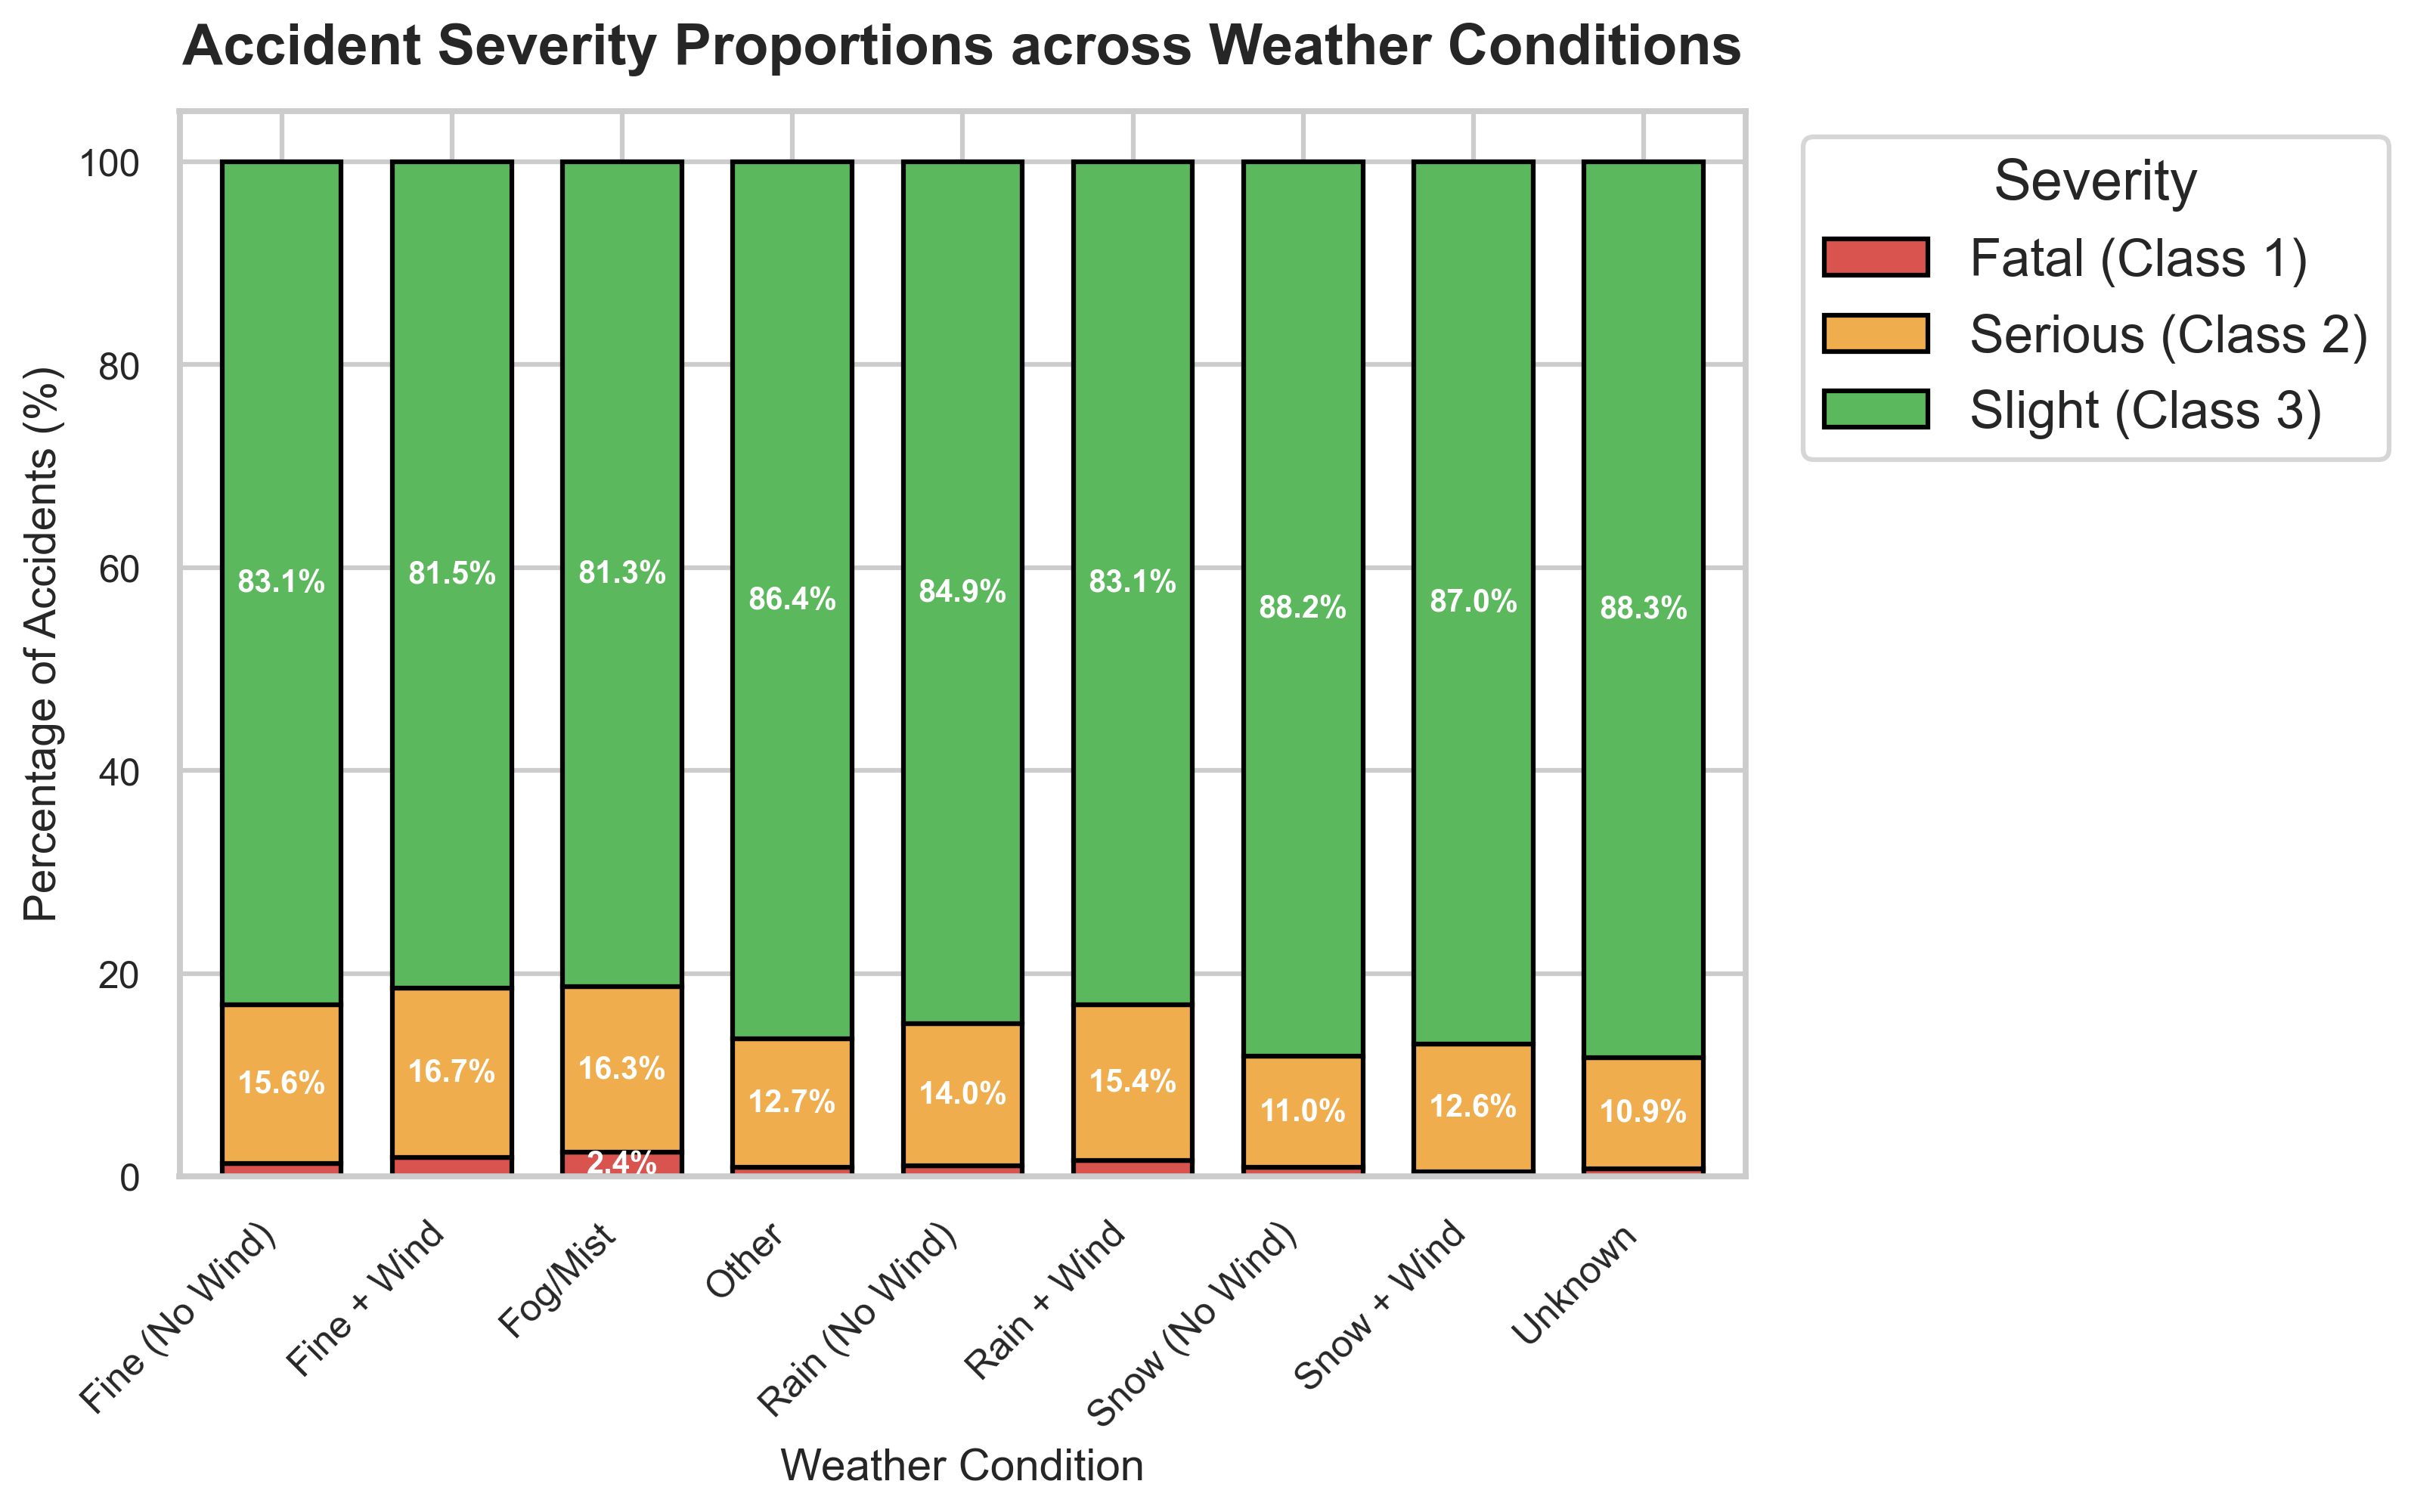


=== Light Severity Proportions ===


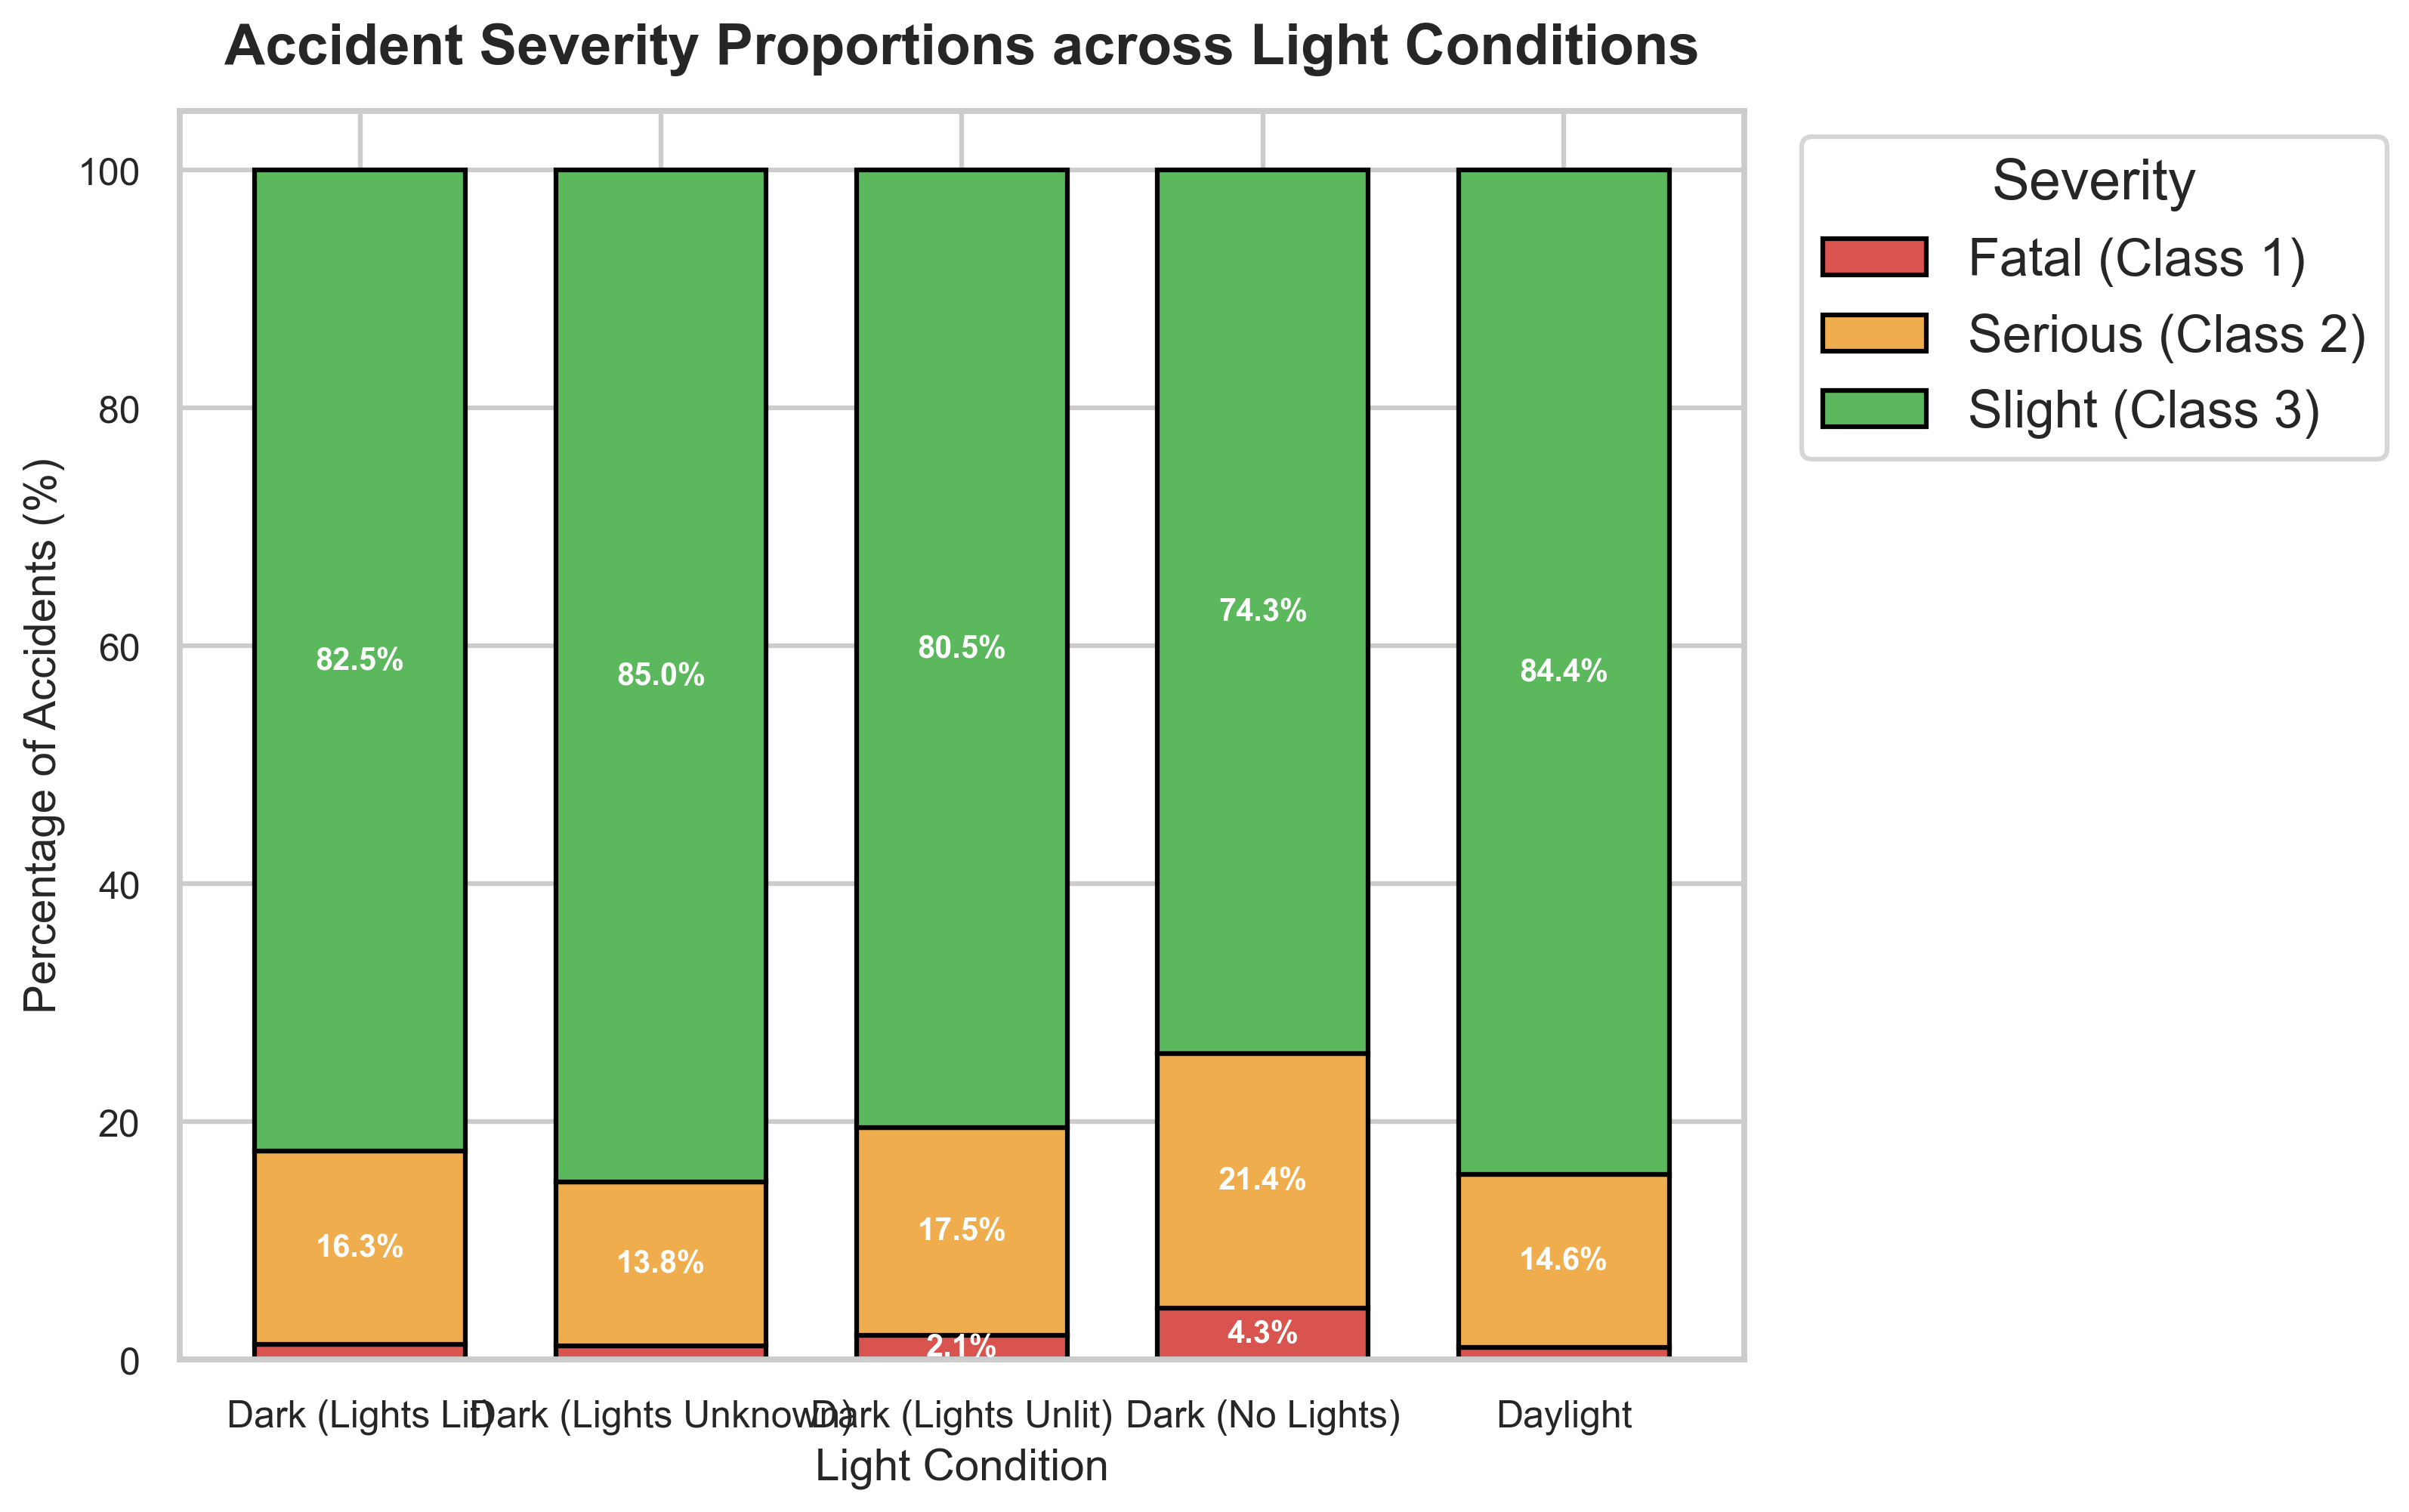

In [6]:
print("=== Weather Severity Proportions ===")
display(Image(filename=bivariate_plots['weather']))

print("\n=== Light Severity Proportions ===")
display(Image(filename=bivariate_plots['light']))


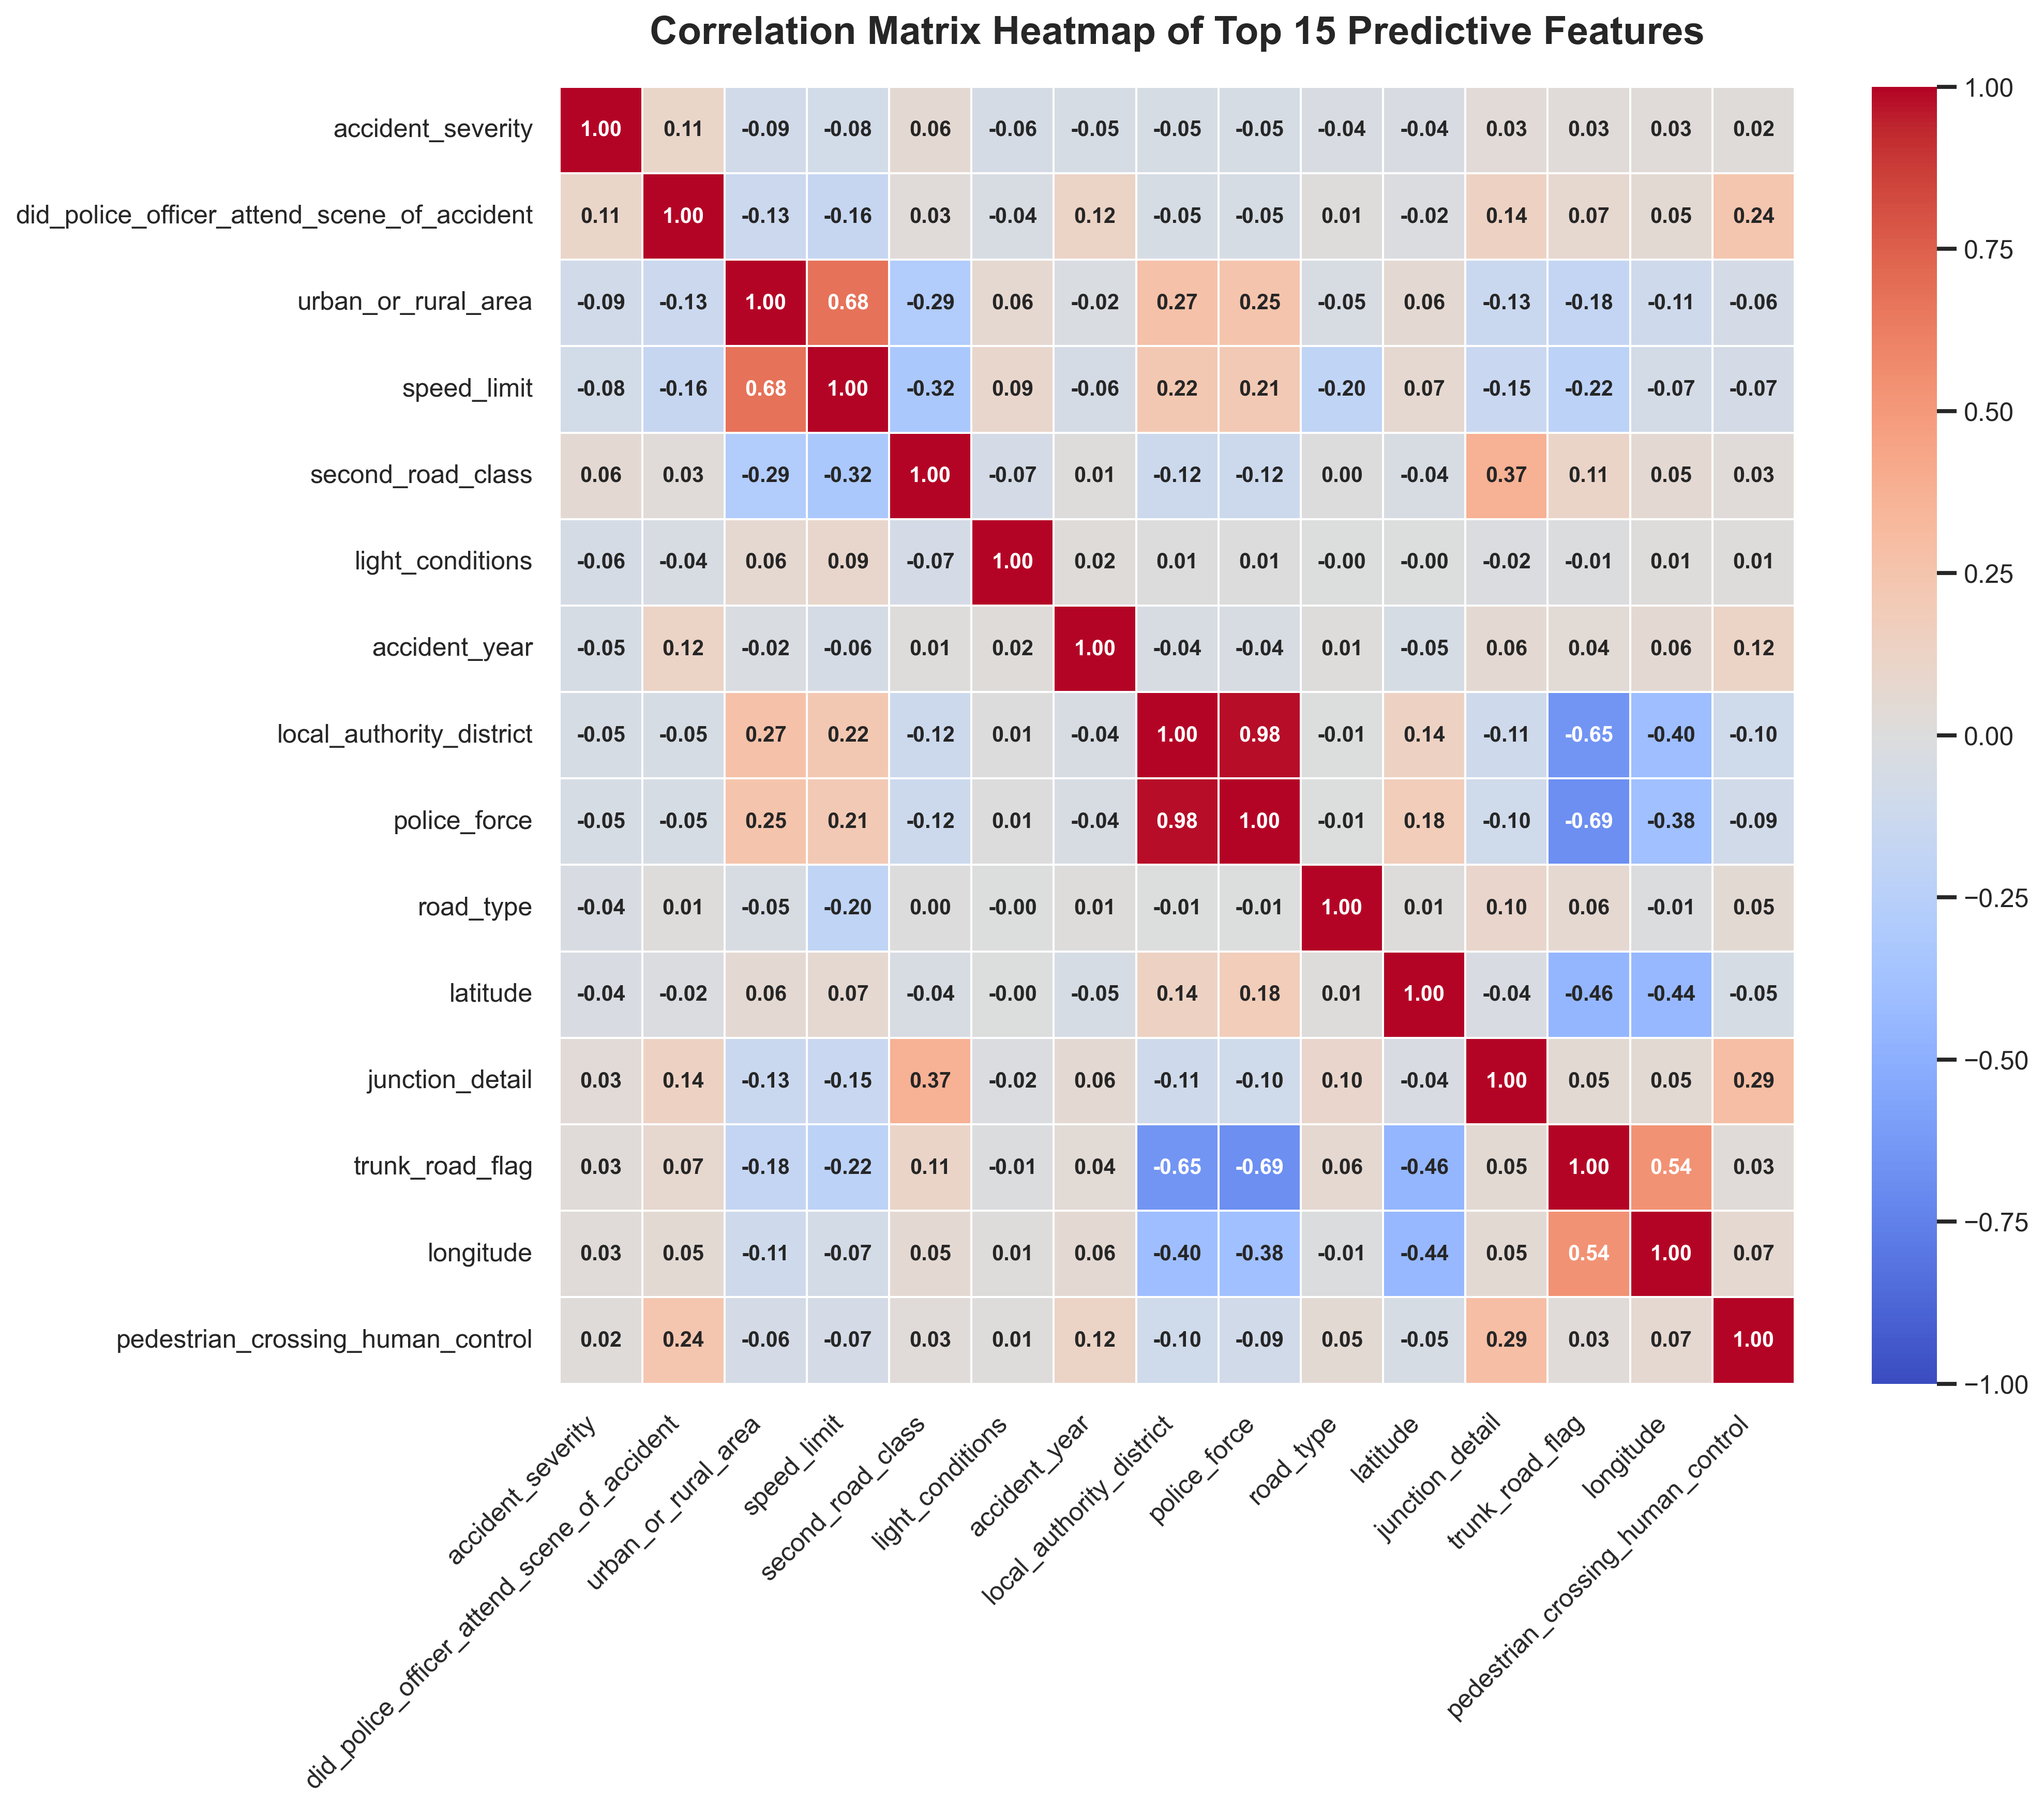

In [7]:
from src.statistical_tests import plot_correlation_heatmap

corr_heatmap_path = plot_correlation_heatmap(df)
display(Image(filename=corr_heatmap_path))


In [8]:
from src.statistical_tests import run_inferential_tests

chi_df, kw_df = run_inferential_tests(df)

print("=== CHI-SQUARE TESTS OF INDEPENDENCE ===")
display(chi_df)

print("\n=== KRUSKAL-WALLIS H-TESTS (NUMERIC FEATURES) ===")
display(kw_df)


=== CHI-SQUARE TESTS OF INDEPENDENCE ===


,Feature,Chi-Square Stat,Degrees of Freedom,p-value,Cramer's V,Association Strength
1,speed_limit,22753.525,16,0.000e+00,0.0794,Weak
0,urban_or_rural_area,15331.784,6,0.000e+00,0.0652,Negligible / Very Weak
5,junction_detail,13452.947,20,0.000e+00,0.0611,Negligible / Very Weak
2,light_conditions,12147.944,8,0.000e+00,0.0580,Negligible / Very Weak
7,time_of_day,6402.561,6,0.000e+00,0.0421,Negligible / Very Weak
3,weather_conditions,1854.258,16,0.000e+00,0.0227,Negligible / Very Weak
4,road_surface_conditions,862.614,10,7.057e-179,0.0155,Negligible / Very Weak
8,season,503.950,6,1.185e-105,0.0118,Negligible / Very Weak
6,is_weekend,16.554,2,2.543e-04,0.0030,Negligible / Very Weak



=== KRUSKAL-WALLIS H-TESTS (NUMERIC FEATURES) ===


,Numeric Feature,H-Statistic,p-value,Statistically Significant
0,speed_limit,15046.485,0.000e+00,Yes (p < 0.001)
1,accident_hour,282.717,4.063e-62,Yes (p < 0.001)
